# Biomassebildung und Rührgeschwindigkeit

Ein Biotechnologe untersucht den Einfluss der Rührgeschwindigkeit auf die Biomassebildung.

Die Fermentationen werden an vier verschiedenen Versuchstagen durchgeführt.

Da sich die Versuchsbedingungen von Tag zu Tag geringfügig unterscheiden können, wird der Versuchstag als Block betrachtet.

## Faktor

Rührgeschwindigkeit

- 100 rpm
- 200 rpm
- 300 rpm
- 400 rpm

## Blockfaktor

Versuchstag

- Tag 1
- Tag 2
- Tag 3
- Tag 4

## Antwortvariable

Biomassekonzentration [g/L]

## Ziele der Analyse

- Randomized Complete Block Design
- ANOVA mit Blockfaktor
- Mittelwertvergleich
- Residuenanalyse

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Day":[
        1,1,1,1,
        2,2,2,2,
        3,3,3,3,
        4,4,4,4
    ],
    "RPM":[
        100,200,300,400,
        100,200,300,400,
        100,200,300,400,
        100,200,300,400
    ],
    "Biomass":[
        6.6, 7.9, 9.8, 8.8,
        7.1, 8.1,10.0, 9.4,
        7.4, 8.8,10.4, 9.9,
        8.0, 9.0,11.1,10.1
    ]
})

In [2]:
table = df.pivot(
    index="Day",
    columns="RPM",
    values="Biomass"
)

table

RPM,100,200,300,400
Day,,,,
1,6.6,7.9,9.8,8.8
2,7.1,8.1,10.0,9.4
3,7.4,8.8,10.4,9.9
4,8.0,9.0,11.1,10.1


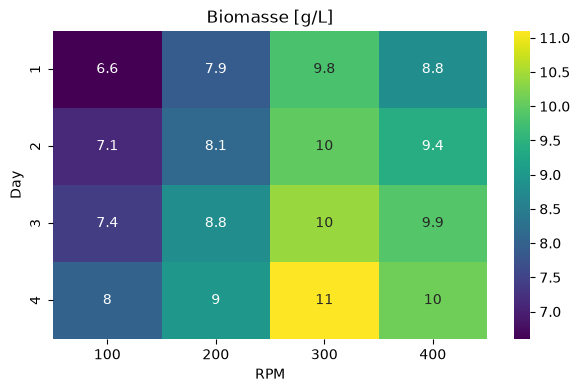

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.heatmap(
    table,
    annot=True,
    cmap="viridis"
)

plt.title(
    "Biomasse [g/L]"
)

plt.show()

In [4]:
rpm_summary = (
    df.groupby("RPM")["Biomass"]
      .agg(
          ["count","mean","std"]
      )
)

rpm_summary

,count,mean,std
RPM,,,
100,4,7.275,0.585235
200,4,8.450,0.532291
300,4,10.325,0.573730
400,4,9.550,0.580230


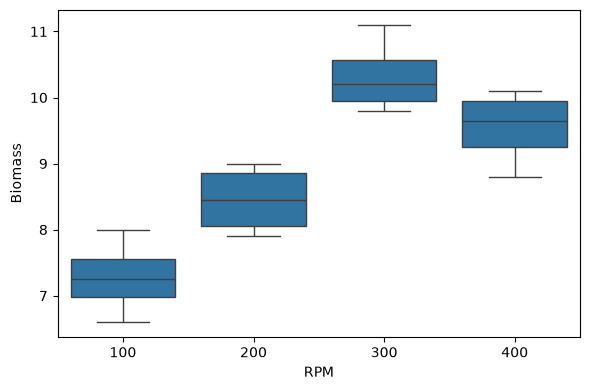

In [5]:
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(
    data=df,
    x="RPM",
    y="Biomass",
    ax=ax
)

fig.tight_layout()

#plt.savefig("biomass_boxplot.pdf",bbox_inches="tight")

plt.show()

In [6]:
day_summary = (
    df.groupby("Day")["Biomass"]
      .agg(
          ["count","mean","std"]
      )
)

day_summary

,count,mean,std
Day,,,
1,4,8.275,1.359841
2,4,8.650,1.302562
3,4,9.125,1.330100
4,4,9.550,1.342882


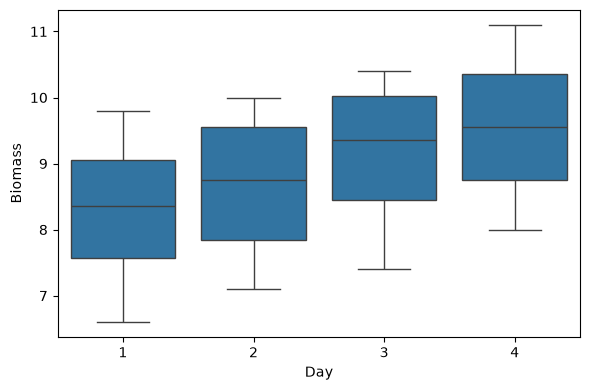

In [7]:
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Day",
    y="Biomass",
    ax=ax
)

fig.tight_layout()

#plt.savefig("biomass_boxplot2.pdf",bbox_inches="tight")

plt.show()

In [8]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols(
    "Biomass ~ C(RPM)+C(Day)",
    data=df
).fit()

anova_table = anova_lm(
    model,
    typ=2
)

anova_table["MS"] = (
    anova_table["sum_sq"]
    /
    anova_table["df"]
)

anova_table

,sum_sq,df,F,PR(>F),MS
C(RPM),21.185,3.0,373.852941,9.239161e-10,7.061667
C(Day),3.705,3.0,65.382353,1.970774e-06,1.235000
Residual,0.170,9.0,NaN,NaN,0.018889


In [9]:
anova_table["Percent"] = (
    100
    *
    anova_table["sum_sq"]
    /
    anova_table["sum_sq"].sum()
)

anova_table

,sum_sq,df,F,PR(>F),MS,Percent
C(RPM),21.185,3.0,373.852941,9.239161e-10,7.061667,84.537111
C(Day),3.705,3.0,65.382353,1.970774e-06,1.235000,14.784517
Residual,0.170,9.0,NaN,NaN,0.018889,0.678372


In [10]:
model_block = ols(
    "Biomass ~ C(RPM)+C(Day)",
    data=df
).fit()

anova_lm(
    model_block,
    typ=2
)

,sum_sq,df,F,PR(>F)
C(RPM),21.185,3.0,373.852941,9.239161e-10
C(Day),3.705,3.0,65.382353,1.970774e-06
Residual,0.170,9.0,NaN,NaN


In [11]:
model_crd = ols(
    "Biomass ~ C(RPM)",
    data=df
).fit()

anova_table2=anova_lm(
    model_crd,
    typ=2
)

anova_table2["MS"] = (
    anova_table2["sum_sq"]
    /
    anova_table2["df"]
)

anova_table2

,sum_sq,df,F,PR(>F),MS
C(RPM),21.185,3.0,21.868387,0.000037,7.061667
Residual,3.875,12.0,NaN,NaN,0.322917


In [12]:
mse_rcbd = (
    anova_lm(
        model_block,
        typ=2
    )
    .loc["Residual","sum_sq"]
    /
    anova_lm(
        model_block,
        typ=2
    )
    .loc["Residual","df"]
)

mse_crd = (
    anova_lm(
        model_crd,
        typ=2
    )
    .loc["Residual","sum_sq"]
    /
    anova_lm(
        model_crd,
        typ=2
    )
    .loc["Residual","df"]
)

print("MSE mit Blockung:", mse_rcbd)
print("MSE ohne Blockung:", mse_crd)

MSE mit Blockung: 0.018888888888888913
MSE ohne Blockung: 0.3229166666666666


In [13]:
means = (
    df.groupby("RPM")
      ["Biomass"]
      .mean()
)

from scipy.stats import t
import numpy as np

alpha = 0.05

MSE = anova_table.loc[
    "Residual",
    "MS"
]

n = 4

df_error = int(
    anova_table.loc[
        "Residual",
        "df"
    ]
)

tcrit = t.ppf(
    1-alpha/2,
    df_error
)

LSD = (
    tcrit
    *
    np.sqrt(
        2*MSE/n
    )
)

print(f"MSE = {MSE:.3f}")
print(f"t critical = {tcrit:.3f}")
print(f"LSD = {LSD:.3f}")



MSE = 0.019
t critical = 2.262
LSD = 0.220


In [14]:
from itertools import combinations

rows = []

for a,b in combinations(
    means.index,
    2
):

    diff = abs(
        means[a]-means[b]
    )

    rows.append(
        {
            "Vergleich":
                f"{a} vs {b}",
            "Differenz":
                diff,
            "LSD":
                LSD,
            "Signifikant":
                diff > LSD
        }
    )

pd.DataFrame(rows)

,Vergleich,Differenz,LSD,Signifikant
0,100 vs 200,1.175,0.219842,True
1,100 vs 300,3.050,0.219842,True
2,100 vs 400,2.275,0.219842,True
3,200 vs 300,1.875,0.219842,True
4,200 vs 400,1.100,0.219842,True
5,300 vs 400,0.775,0.219842,True


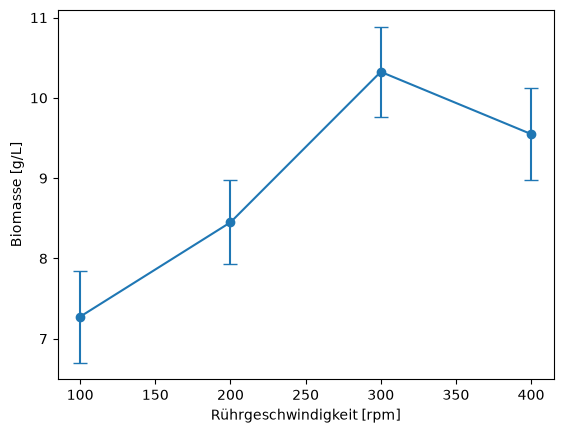

In [15]:
means = (
    df.groupby("RPM")
      ["Biomass"]
      .mean()
)

std = (
    df.groupby("RPM")
      ["Biomass"]
      .std()
)

ci = (
    1.96
    *
    std
    /
    (4**0.5)
)

plt.errorbar(
    means.index,
    means,
    yerr=ci,
    fmt="o-",
    capsize=5
)

plt.xlabel(
    "Rührgeschwindigkeit [rpm]"
)

plt.ylabel(
    "Biomasse [g/L]"
)

plt.show()

<Axes: xlabel='Day', ylabel='Residual'>

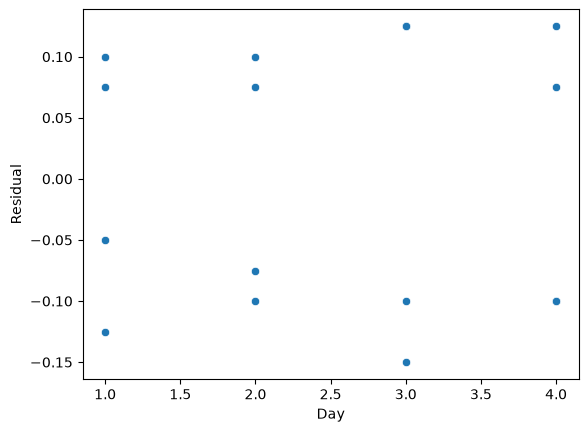

In [16]:
sns.scatterplot(
    data=df.assign(
        Residual=model.resid
    ),
    x="Day",
    y="Residual"
)

In [17]:
from statsmodels.regression.mixed_linear_model import MixedLM

mixed = MixedLM.from_formula(
    "Biomass ~ C(RPM)",
    groups="Day",
    data=df
)

result = mixed.fit()

print(
    result.summary()
)

         Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Biomass
No. Observations:   16      Method:             REML   
No. Groups:         4       Scale:              0.0189 
Min. group size:    4       Log-Likelihood:     -2.2551
Max. group size:    4       Converged:          Yes    
Mean group size:    4.0                                
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     7.275    0.284 25.605 0.000  6.718  7.832
C(RPM)[T.200] 1.175    0.097 12.091 0.000  0.985  1.365
C(RPM)[T.300] 3.050    0.097 31.384 0.000  2.860  3.240
C(RPM)[T.400] 2.275    0.097 23.410 0.000  2.085  2.465
Day Var       0.304    2.118                           



In [18]:
sigma_day = (
    result.cov_re.iloc[0,0]
)

sigma_error = (
    result.scale
)

total = (
    sigma_day
    +
    sigma_error
)

print(
    f"Tag-Varianz: {sigma_day:.3f}"
)

print(
    f"Fehlervarianz: {sigma_error:.3f}"
)

print(
    f"Anteil Tag: "
    f"{100*sigma_day/total:.1f}%"
)

Tag-Varianz: 0.304
Fehlervarianz: 0.019
Anteil Tag: 94.2%


# Biomassebildung: Lateinisches Quadrat

Neben dem Versuchstag könnte auch die Bedienperson die Ergebnisse beeinflussen.

Zur gleichzeitigen Kontrolle beider Störfaktoren wird ein Lateinisches Quadrat verwendet.

## Behandlung

Rührgeschwindigkeit

## Störfaktor 1

Versuchstag

## Störfaktor 2

Bedienperson

## Antwortvariable

Biomassekonzentration [g/L]

In [19]:
latin = pd.DataFrame({

    "Day":[
        1,1,1,1,
        2,2,2,2,
        3,3,3,3,
        4,4,4,4
    ],

    "Operator":[
        "A","B","C","D",
        "A","B","C","D",
        "A","B","C","D",
        "A","B","C","D"
    ],

    "RPM":[
        100,200,300,400,
        200,300,400,100,
        300,400,100,200,
        400,100,200,300
    ],

    "Biomass":[
        7.3,8.4,10.4,9.3,
        8.2,10.2,9.2,6.8,
        10.7,9.6,7.4,8.5,
        9.1,7.0,8.3,10.1
    ]
})

latin

,Day,Operator,RPM,Biomass
0,1,A,100,7.3
1,1,B,200,8.4
2,1,C,300,10.4
3,1,D,400,9.3
4,2,A,200,8.2
5,2,B,300,10.2
6,2,C,400,9.2
7,2,D,100,6.8
8,3,A,300,10.7
9,3,B,400,9.6


In [20]:
model = ols(
    "Biomass ~ C(RPM)+C(Day)+C(Operator)",
    data=latin
).fit()

anova_lm(
    model,
    typ=2
)

,sum_sq,df,F,PR(>F)
C(RPM),22.636875,3.0,1574.739130,4.462229e-09
C(Day),0.536875,3.0,37.347826,2.817282e-04
C(Operator),0.061875,3.0,4.304348,6.092170e-02
Residual,0.028750,6.0,NaN,NaN
